# ViT Linear Probe — Oxford-IIIT Pet Dataset

Trains a frozen ViT-Base backbone with only the classification head unfrozen (Linear Probing).

**Setup:**
- Model: `ViTLinearProbe` (backbone frozen, head trainable)
- Dataset: Oxford-IIIT Pet (37 breed classes)
- Optimizer: Adam
- LR Scheduler: ReduceLROnPlateau (patience=3)
- Early Stopping: patience=5 on validation loss
- Device target: NVIDIA RTX 3070 Ti Laptop GPU

## 1. Imports & Environment Check

In [42]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import csv
from datetime import datetime

sys.path.insert(0, "../Models")
sys.path.insert(0, "../DataLoader")
sys.path.insert(0, "../Training")

from DataLoader import build_dataloaders, BatchAugmenter
from ViTFinetune  import ViTLinearProbe
from TrainingEngine import TrainingEngine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
if device.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.5.1+cu121
Device   : cuda
GPU      : NVIDIA GeForce RTX 3070 Ti Laptop GPU
VRAM     : 8.6 GB


## 2. Configuration

> **Set `DATASET_ROOT`** to the folder that contains `images/` and `annotations/`.

In [43]:
TRAINING_TYPE = "Linear_Probe"
AUGS = "Adv_Augs"
DATASET_ROOT = "../../../Dataset/"

BATCH_SIZE = 64 
NUM_EPOCHS = 30
IMAGE_SIZE = 224
VAL_SPLIT = 0.2
NUM_WORKERS = 4
SEED = 42

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

LR_PATIENCE = 2
LR_FACTOR = 0.1
LR_MIN  = 1e-6 

# ── early stopping ────────────────────────────────────────────────────────────
ES_PATIENCE  = 5
LABEL_MODE = "breed"

if LABEL_MODE == "breed":
    NUM_CLASSES  = 37

elif LABEL_MODE == "species":
    NUM_CLASSES  = 2


else:
    raise ValueError(f"LABEL_MODE must be 'breed' or 'species', got '{LABEL_MODE}'")

print(f"Label mode : {LABEL_MODE} ({NUM_CLASSES} classes)")

MODEL_NAME = "vit_base_patch16_224"

Label mode : breed (37 classes)


## 3. DataLoaders

In [44]:
AUGMENTATIONS = {
    "horizontal_flip": True, 
    
    "rotation": True, 
        "rotation_min_degrees": 0,
        "rotation_max_degrees": 20,
    
    "random_crop": True,  
        "crop_scale": (0.85, 1.0), 
        "crop_ratio": (0.9, 1.1), 
    
    "color_jitter": True, 
        "jitter_brightness": 0.3, 
        "jitter_contrast": 0.3, 
        "jitter_saturation": 0.2, 
        "jitter_hue": 0.05,
    
    "grayscale": True, 
        "grayscale_p": 0.05,
    
    "random_erasing":  False,  
        "erasing_p": 0.3, 
        "erasing_scale": (0.02, 0.10),
    
    "batch_aug_prob": 0.3,
        "mixup": True,  
            "mixup_alpha":  0.4,
        "cutmix": True,  
            "cutmix_alpha": 1.0,
}
if AUGMENTATIONS["random_erasing"]:
    AUGS += "_"+"random_erasing" +"_"
if AUGMENTATIONS["mixup"]:
    AUGS += "_"+"mixup" +"_"
if AUGMENTATIONS["cutmix"]:
    AUGS += "_"+"cutmix" +"_"
if AUGMENTATIONS["mixup"] or AUGMENTATIONS["cutmix"]:
     AUGS += "_"+"batch_aug_prob" +"_"+str(AUGMENTATIONS["batch_aug_prob"])

In [45]:
train_loader, val_loader, test_loader = build_dataloaders(
    dataset_root= DATASET_ROOT,
    val_split = VAL_SPLIT,
    batch_size = BATCH_SIZE,
    one_hot = False,
    image_size = IMAGE_SIZE,
    augs = AUGMENTATIONS,
    num_workers = NUM_WORKERS,
    seed = SEED,
)

class LabelSelector:
    def __init__(self, loader, mode):
        self.loader = loader
        self.mode   = mode

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        for x, (y1, y2) in self.loader:
            yield x, (y2 if self.mode == "breed" else y1)

train_selector = LabelSelector(train_loader, LABEL_MODE)
val_selector   = LabelSelector(val_loader,   LABEL_MODE)
test_selector  = LabelSelector(test_loader,  LABEL_MODE)

print(f"\nBatches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Dataset split — train: 2944 | val: 736 | test: 3669
Label format  — integer index | y1: species (Cat/Dog) | y2: breed (0–36)

Batches — train: 46 | val: 12 | test: 58


## 4. Model, Loss, Optimizer & Scheduler

In [46]:
model = ViTLinearProbe(num_classes=NUM_CLASSES, model_name=MODEL_NAME)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable_params:>12,}")
print(f"Frozen    : {total_params - trainable_params:>12,}")
print(f"Total     : {total_params:>12,}")

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model.trainable_params(),
    lr = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = LR_FACTOR,
    patience = LR_PATIENCE,
    min_lr = LR_MIN,
    verbose = True,
)

Trainable :       28,453
Frozen    :   85,798,656
Total     :   85,827,109


C:\Users\bhasw\Documents\DeepLearning\Code\Deep_Learning_Project\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 5. Training Engine

In [47]:
batch_augmenter = BatchAugmenter(augs=AUGMENTATIONS, num_classes=NUM_CLASSES)

engine = TrainingEngine(
    network        = model,
    data_iterator  = train_selector,
    loss_fn        = loss_fn,
    opt            = optimizer,
    compute_device = device,
    scheduler      = None,
    batch_aug      = batch_augmenter,
)

## 6. Early-Stopping Helper

In [48]:
class EarlyStopping:
    """
    Stops training when validation loss has not improved for `patience` epochs.
    Also saves the best model weights to `save_path`.
    """

    def __init__(self, patience: int = 5, save_path: str = "best_model.pt", delta: float = 1e-4):
        self.patience = patience
        self.save_path = save_path
        self.delta = delta
        self.best_loss  = float("inf")
        self.counter = 0
        self.stop  = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter  = 0
            torch.save(model.state_dict(), self.save_path)
            print(f" New best val_loss={val_loss:.4f} — checkpoint saved to '{self.save_path}'")
        else:
            self.counter += 1
            print(f" Early-stop counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
                print("Early stopping triggered.")

CHECKPOINT_BASE = "../Checkpoints/"
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

CHECKPOINT_DIR = CHECKPOINT_BASE+MODEL_NAME+"_"+TRAINING_TYPE+"_"+LABEL_MODE+"_"+AUGS
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Checkpoint directory: {os.path.abspath(CHECKPOINT_DIR)}")
early_stopping = EarlyStopping(patience=ES_PATIENCE, save_path=CHECKPOINT_DIR+"/checkpoint.pt")

Checkpoint directory: C:\Users\bhasw\Documents\DeepLearning\Code\Deep_Learning_Project\Checkpoints\vit_base_patch16_224_Linear_Probe_breed_Adv_Augs_mixup__batch_aug_prob_0.3


## 7. Training Loop

In [49]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   [], "val_f1": []}

print(f"Starting training for up to {NUM_EPOCHS} epochs ...\n")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n── Epoch {epoch}/{NUM_EPOCHS} ──")

    train_stats = engine.train_one_epoch(epoch_num=epoch, print_freq=50)

    val_stats = engine.evaluate(val_selector, phase_label="Validation")

    history["train_loss"].append(train_stats["epoch_loss"])
    history["train_acc"].append(train_stats["epoch_acc"])
    history["val_loss"].append(val_stats["epoch_loss"])
    history["val_acc"].append(val_stats["epoch_acc"])
    history["val_f1"].append(val_stats["macro_f1"])

    # ── LR scheduler (ReduceLROnPlateau) ──────────────────────────────────────
    scheduler.step(val_stats["epoch_loss"])
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Current LR: {current_lr:.2e}")

    # ── early stopping ────────────────────────────────────────────────────────
    early_stopping(val_stats["epoch_loss"], model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch}.")
        break

print("\n" + "=" * 70)
print("Training complete.")
print(f"Best val_loss : {early_stopping.best_loss:.4f}")
print(f"Best model    : best_vit_linear_probe.pt")

Starting training for up to 30 epochs ...


── Epoch 1/30 ──


[Epoch 001] Train: 100%|███████████████████████████████████| 46/46 [00:18<00:00,  2.51batch/s, acc=67.97%, loss=1.8089]


[Epoch 001] COMPLETED | avg_loss=1.8089 | avg_acc=0.6797


[Validation]      : 100%|██████████████████████████████████| 12/12 [00:05<00:00,  2.24batch/s, acc=89.54%, loss=1.0448]


[VALIDATION] metrics | Mean Loss: 1.0448 | Accuracy: 89.54% | Macro F1: 88.99% | Macro P:  90.12% | Macro R:  89.26%
  Current LR: 1.00e-03
 New best val_loss=1.0448 — checkpoint saved to '../Checkpoints/vit_base_patch16_224_Linear_Probe_breed_Adv_Augs_mixup__batch_aug_prob_0.3/checkpoint.pt'

── Epoch 2/30 ──


...

[VALIDATION] metrics | Mean Loss: 0.9294 | Accuracy: 92.12% | Macro F1: 91.77% | Macro P:  92.24% | Macro R:  91.76%
  Current LR: 1.00e-04
 Early-stop counter: 4/5

── Epoch 14/30 ──


[Epoch 014] Train: 100%|███████████████████████████████████| 46/46 [00:18<00:00,  2.42batch/s, acc=97.08%, loss=0.9538]


[Epoch 014] COMPLETED | avg_loss=0.9538 | avg_acc=0.9708


[Validation]      : 100%|██████████████████████████████████| 12/12 [00:05<00:00,  2.17batch/s, acc=92.39%, loss=0.9283]

[VALIDATION] metrics | Mean Loss: 0.9283 | Accuracy: 92.39% | Macro F1: 92.03% | Macro P:  92.51% | Macro R:  92.06%
  Current LR: 1.00e-04
 Early-stop counter: 5/5
Early stopping triggered.

Training stopped early at epoch 14.

Training complete.
Best val_loss : 0.9235
Best model    : best_vit_linear_probe.pt


## 8. Training Curves

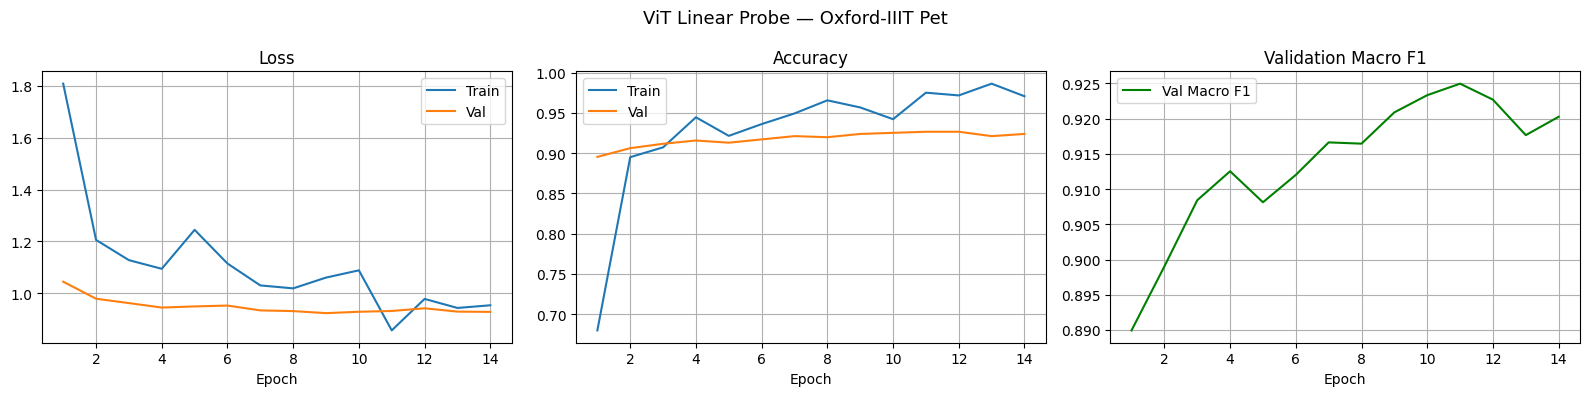

Plot saved to training_curves.png


In [50]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs_ran, history["train_loss"], label="Train")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs_ran, history["train_acc"], label="Train")
axes[1].plot(epochs_ran, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# Macro F1
axes[2].plot(epochs_ran, history["val_f1"], label="Val Macro F1", color="green")
axes[2].set_title("Validation Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("ViT Linear Probe — Oxford-IIIT Pet", fontsize=13)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR+"/training_curves.png", dpi=150)
plt.show()
print("Plot saved to training_curves.png")

## 9. Test Evaluation (Best Checkpoint)

In [51]:
print("Loading best checkpoint ...")
model.load_state_dict(torch.load(CHECKPOINT_DIR+"/checkpoint.pt", map_location=device))
model.to(device)

test_stats = engine.evaluate(test_selector, phase_label="Test")

print("\n── Final Test Results ──────────────────────────────")
print(f"  Loss      : {test_stats['epoch_loss']:.4f}")
print(f"  Accuracy  : {test_stats['epoch_acc']*100:.2f}%")
print(f"  Macro F1  : {test_stats['macro_f1']*100:.2f}%")
print(f"  Macro P   : {test_stats['macro_precision']*100:.2f}%")
print(f"  Macro R   : {test_stats['macro_recall']*100:.2f}%")



results = {
    "timestamp":  datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":      MODEL_NAME,
    "label_mode": LABEL_MODE,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "epochs_ran": len(history["train_loss"]),
    "loss":       round(test_stats["epoch_loss"], 4),
    "accuracy":   round(test_stats["epoch_acc"] * 100, 2),
    "macro_f1":   round(test_stats["macro_f1"] * 100, 2),
    "macro_p":    round(test_stats["macro_precision"] * 100, 2),
    "macro_r":    round(test_stats["macro_recall"] * 100, 2),
    "augmentations": str(AUGMENTATIONS), 
}

csv_path   = os.path.join(CHECKPOINT_DIR, "test_results.csv")
file_exists = os.path.isfile(csv_path)

with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results.keys())
    if not file_exists:
        writer.writeheader()    # only write header once
    writer.writerow(results)

print(f"\nResults saved to {csv_path}")

C:\Users\bhasw\AppData\Local\Temp\ipykernel_26456\2816777593.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_DIR+"/checkpoint

Loading best checkpoint ...


[Test]      : 100%|████████████████████████████████████████| 58/58 [00:18<00:00,  3.13batch/s, acc=91.47%, loss=0.9764]

[TEST] metrics | Mean Loss: 0.9764 | Accuracy: 91.47% | Macro F1: 91.38% | Macro P:  91.65% | Macro R:  91.40%

── Final Test Results ──────────────────────────────
  Loss      : 0.9764
  Accuracy  : 91.47%
  Macro F1  : 91.38%
  Macro P   : 91.65%
  Macro R   : 91.40%

Results saved to ../Checkpoints/vit_base_patch16_224_Linear_Probe_breed_Adv_Augs_mixup__batch_aug_prob_0.3\test_results.csv
